# 01 · Gram reaction, ID and AST data analysis

**Project:** multi-tier machine learning for digital-microscopy identification and antimicrobial susceptibility testing (ID/AST)

Each row of the dataset is **one broth-microdilution well**: one isolate × one antimicrobial × one two-fold concentration, imaged by digital microscopy.

| Target | Tier | Levels |
|---|---|---|
| `Gram_Reaction` | 1 | Gram Positive (55%) / Gram Negative (45%) |
| `Growth_Status` | 2 | Growth / No Growth per well |
| `MIC_Call_ug_mL` + `MIC_DSI` | 3 | MIC per Gram-positive isolate × drug, with its Dilution Series Index |

This notebook answers: what do the data look like, which features separate Gram-positive from Gram-negative wells, what are the MIC distributions and resistance rates, and how sharply does growth change at the MIC?

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/gram-id-ast-ml


## 1. Load and validate
Only blank cells are treated as missing. `validate` also checks that every Gram-positive series satisfies MIC_DSI = number of growth wells + 1.

In [2]:
from src.data.make_dataset import load_raw, validate, main as make_data, series_table
raw = validate(load_raw())
make_data()          # writes data/interim and the isolate-grouped train/test split
print(raw.shape, "| isolates:", raw[cfg.ISOLATE_ID].nunique(), "| GP isolate-drug series:", len(series_table(raw)))
raw.head()

13:40:04 | INFO    | src.data.make_dataset | Loaded 7320 wells x 30 columns from GramID_AST_digital_microscopy.csv


13:40:04 | INFO    | src.data.make_dataset | Validation passed: {'Gram Positive': 4026, 'Gram Negative': 3294} | {'Growth': 3999, 'No Growth': 3321} | missing cells 8.0%


13:40:04 | INFO    | src.data.make_dataset | Loaded 7320 wells x 30 columns from GramID_AST_digital_microscopy.csv


13:40:04 | INFO    | src.data.make_dataset | Validation passed: {'Gram Positive': 4026, 'Gram Negative': 3294} | {'Growth': 3999, 'No Growth': 3321} | missing cells 8.0%


13:40:05 | INFO    | src.data.make_dataset | Train: 5780 wells, 219 isolates, 367 GP series, Gram+ share 0.548


13:40:05 | INFO    | src.data.make_dataset | Test: 1540 wells, 55 isolates, 99 GP series, Gram+ share 0.556


(7320, 30) | isolates: 274 | GP isolate-drug series: 466


,Well_ID,Isolate_ID,Organism,Specimen_Source,Antimicrobial,Concentration_ug_mL,Well_DSI,Crystal_Violet_Retention,Safranin_Intensity,Stain_Hue_Angle_deg,Cell_Wall_Thickness_nm,KOH_String_Test,Cell_Morphology,Catalase,Resistance_Marker,Inoculum_log10_CFU_mL,Incubation_Time_h,Cell_Count_T0,Cell_Count_T4h,Growth_Fold_Change,Mean_Cell_Area_um2,Cell_Elongation_Index,Occupied_Area_Fraction,Time_to_Detection_h,OD600_Read,Growth_Control_OD600,Gram_Reaction,Growth_Status,MIC_Call_ug_mL,MIC_DSI
0,GP0031-AMP-01,GP0031,Staphylococcus aureus,Wound,Ampicillin,0.12,1,0.718,0.194,297.4,16.0,Negative,Cocci_clusters,Positive,mecA,5.63,18,NaN,1516.0,7.789,1.069,NaN,0.310,NaN,0.634,0.822,Gram Positive,Growth,32,9
1,GP0031-AMP-02,GP0031,Staphylococcus aureus,Wound,Ampicillin,0.25,2,NaN,NaN,290.2,20.5,Negative,Cocci_clusters,Positive,mecA,5.71,18,155.0,1636.0,10.543,1.212,1.011,NaN,1.50,0.666,0.763,Gram Positive,Growth,32,9
2,GP0031-AMP-03,GP0031,Staphylococcus aureus,Wound,Ampicillin,0.50,3,NaN,0.196,280.8,NaN,NaN,NaN,Positive,mecA,5.73,18,130.0,1304.0,10.061,0.934,1.130,0.402,1.97,0.590,0.787,Gram Positive,Growth,32,9
3,GP0031-AMP-04,GP0031,Staphylococcus aureus,Wound,Ampicillin,1.00,4,0.716,0.279,283.4,NaN,Negative,Cocci_clusters,Negative,mecA,5.67,18,116.0,921.0,7.945,1.057,1.130,NaN,2.90,0.622,0.808,Gram Positive,Growth,32,9
4,GP0031-AMP-05,GP0031,Staphylococcus aureus,Wound,Ampicillin,2.00,5,0.786,0.222,269.5,25.2,Negative,Cocci_clusters,Positive,mecA,5.64,18,121.0,899.0,7.401,1.242,1.274,0.286,NaN,0.688,0.766,Gram Positive,Growth,32,9


In [3]:
pd.DataFrame({
    "wells": raw.groupby(cfg.T1_TARGET).size(),
    "isolates": raw.drop_duplicates(cfg.ISOLATE_ID).groupby(cfg.T1_TARGET).size(),
    "share of wells": raw[cfg.T1_TARGET].value_counts(normalize=True).round(3)})

,wells,isolates,share of wells
Gram_Reaction,,,
Gram Negative,3294,147,0.45
Gram Positive,4026,127,0.55


13:40:07 | INFO    | src.analysis.gram_id_analysis | Gram analysis: 6/6 numeric features significant


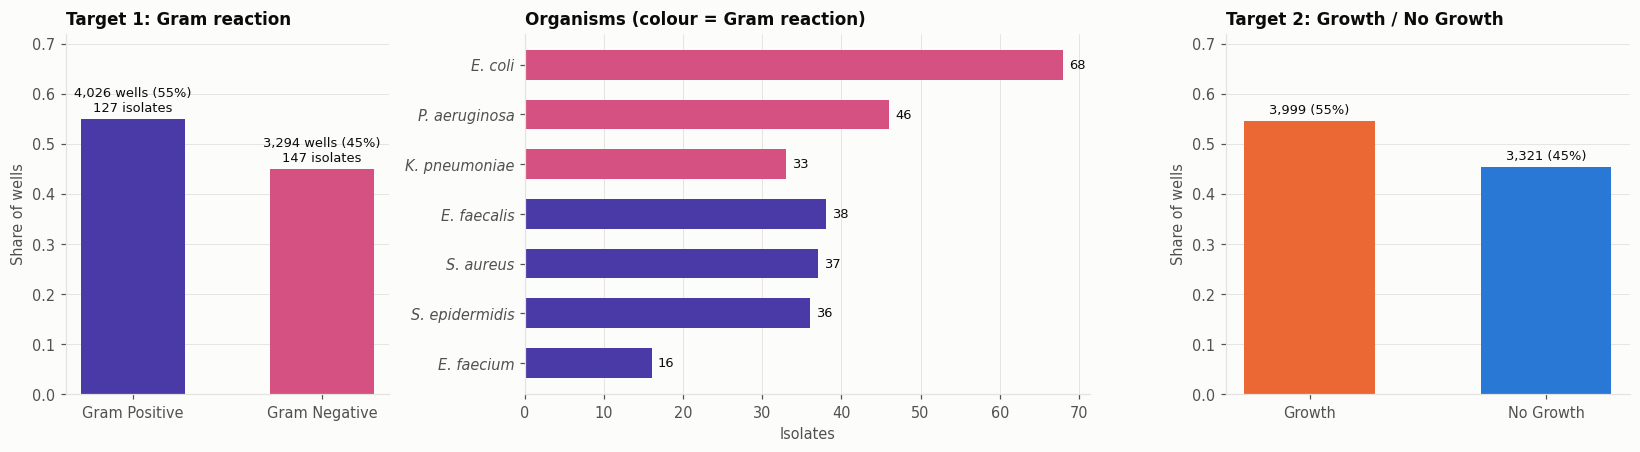

In [4]:
from src.analysis import gram_id_analysis as ga
gres = ga.run(raw); plt.close("all")        # every table and figure, redrawn one by one below
ga.plot_overview(raw);

## 2. Gram reaction features
Mann-Whitney U with Benjamini-Hochberg FDR, rank-biserial effect size and single-feature AUC for the six image-derived Gram features.

In [5]:
gres["numeric_tests"][["feature", "negative_class_median", "positive_class_median", "rank_biserial",
                        "univariate_auc", "q_value"]].round(4)

,feature,negative_class_median,positive_class_median,rank_biserial,univariate_auc,q_value
0,Crystal_Violet_Retention,0.311,0.712,0.8929,0.9465,0.0
1,Safranin_Intensity,0.690,0.288,-0.8613,0.9306,0.0
2,Stain_Hue_Angle_deg,312.800,291.200,-0.8129,0.9064,0.0
3,Cell_Wall_Thickness_nm,12.300,26.400,0.8014,0.9007,0.0
4,Mean_Cell_Area_um2,3.451,0.984,-0.9616,0.9808,0.0
5,Cell_Elongation_Index,4.420,1.289,-0.9553,0.9777,0.0


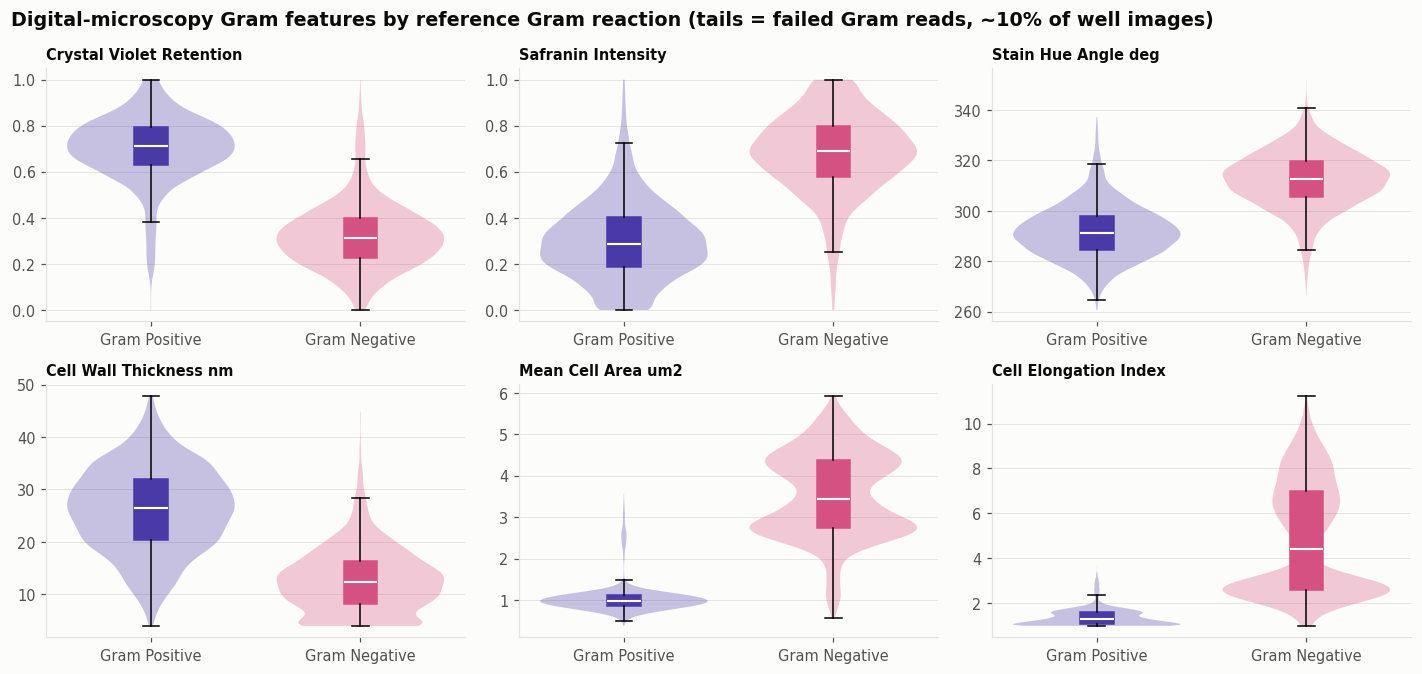

In [6]:
ga.plot_gram_numeric(raw);

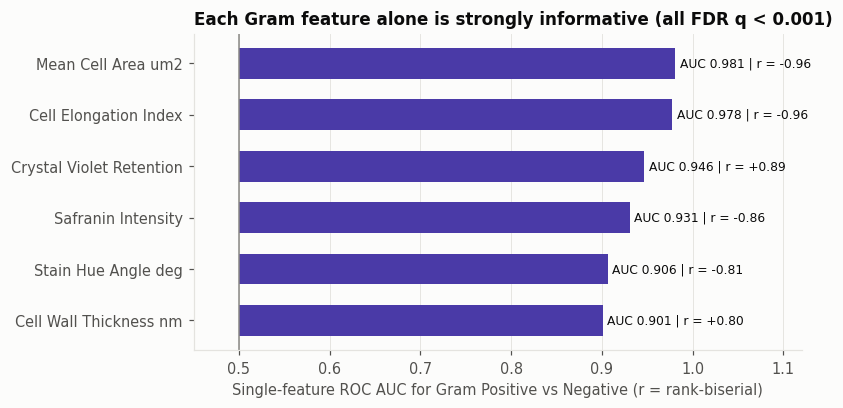

In [7]:
ga.plot_univariate(gres["numeric_tests"]);

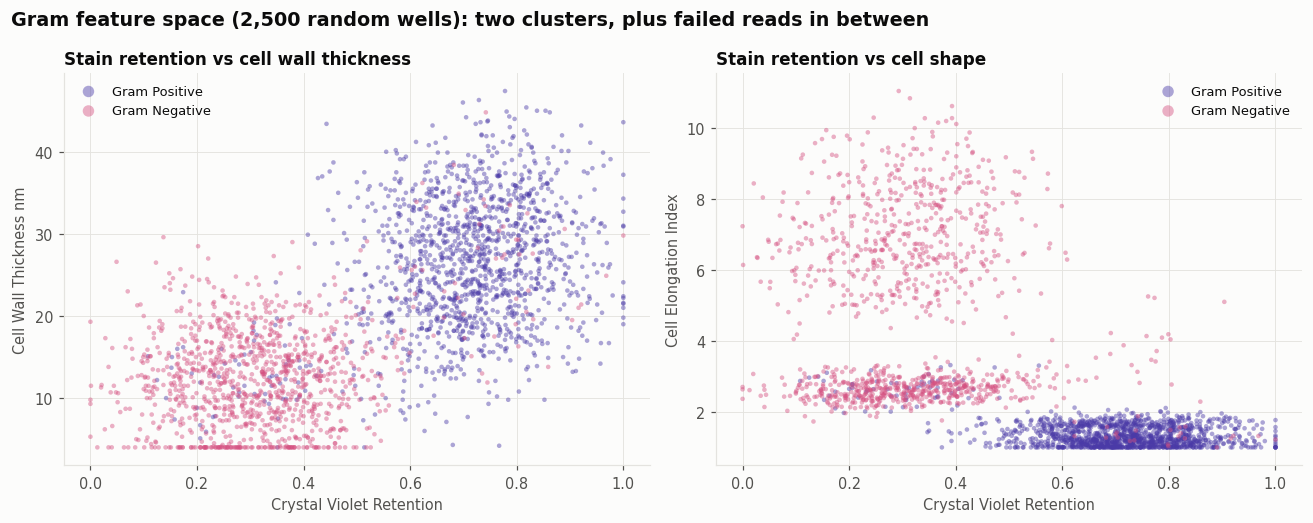

In [8]:
ga.plot_gram_feature_space(raw);

The tails and the points between the two clusters are **failed Gram reads**: out-of-focus fields, over- or under-decolourised smears and debris, in about 10% of well images. A single well image can therefore be wrong. Pooling all well images of an isolate (Tier 1, isolate level) removes most of these errors.

## 3. Identification tests

In [9]:
gres["categorical_tests"].round(4)

,feature,chi2,dof,chi2_p,cramers_v,q_value
0,KOH_String_Test,5456.9309,1,0.0,0.9217,0.0
1,Cell_Morphology,4495.3652,2,0.0,0.8359,0.0
2,Resistance_Marker,1781.9043,5,0.0,0.5276,0.0
3,Catalase,1377.4606,1,0.0,0.4638,0.0
4,Specimen_Source,80.2432,3,0.0,0.1120,0.0


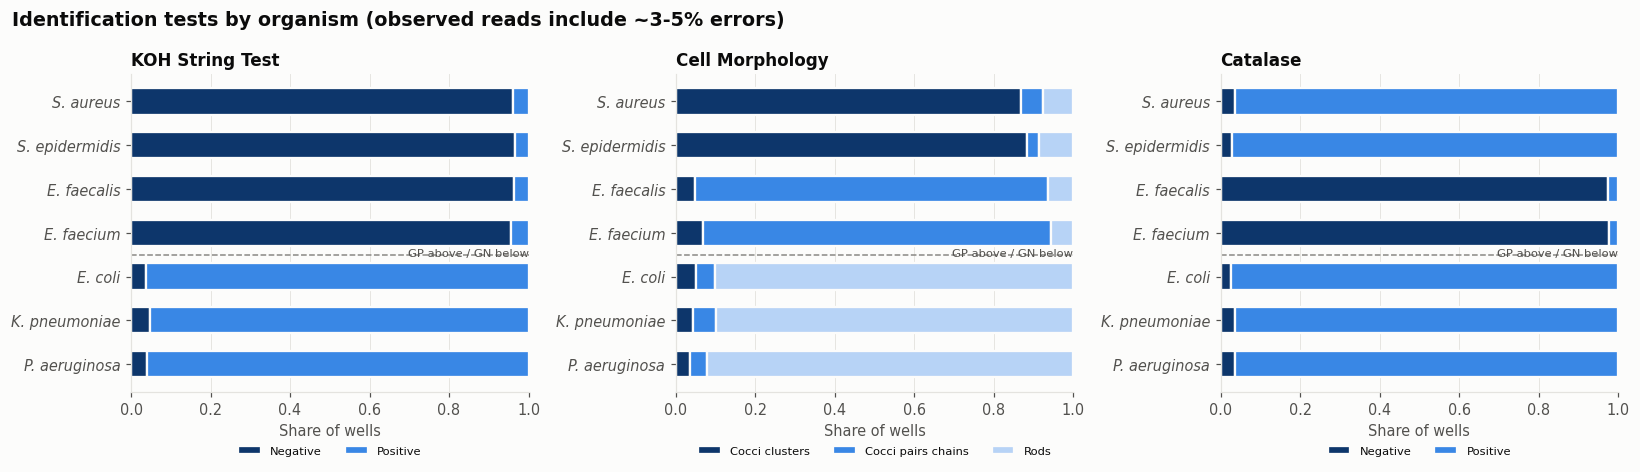

In [10]:
ga.plot_gram_categorical(raw);

In [11]:
gres["medians_by_organism"]

,Crystal_Violet_Retention,Safranin_Intensity,Stain_Hue_Angle_deg,Cell_Wall_Thickness_nm,Mean_Cell_Area_um2,Cell_Elongation_Index
Organism,,,,,,
Staphylococcus aureus,0.714,0.284,290.10,25.0,0.917,1.130
Staphylococcus epidermidis,0.711,0.296,291.20,26.3,0.942,1.110
Enterococcus faecalis,0.712,0.283,291.70,28.5,1.043,1.593
Enterococcus faecium,0.704,0.288,292.40,25.8,1.083,1.621
Escherichia coli,0.305,0.692,313.20,12.6,4.037,6.282
Klebsiella pneumoniae,0.326,0.678,312.10,11.8,3.910,4.953
Pseudomonas aeruginosa,0.308,0.690,312.85,12.2,2.868,2.688


## 4. AST: MIC distributions and antibiogram
Breakpoints come from `data/external/AST_breakpoints_reference.csv` (CLSI M100 where a breakpoint exists, surrogate study cut-offs otherwise).

13:40:14 | INFO    | src.analysis.ast_analysis | AST analysis: 466 GP series, marker concordance [1.0, 1.0]


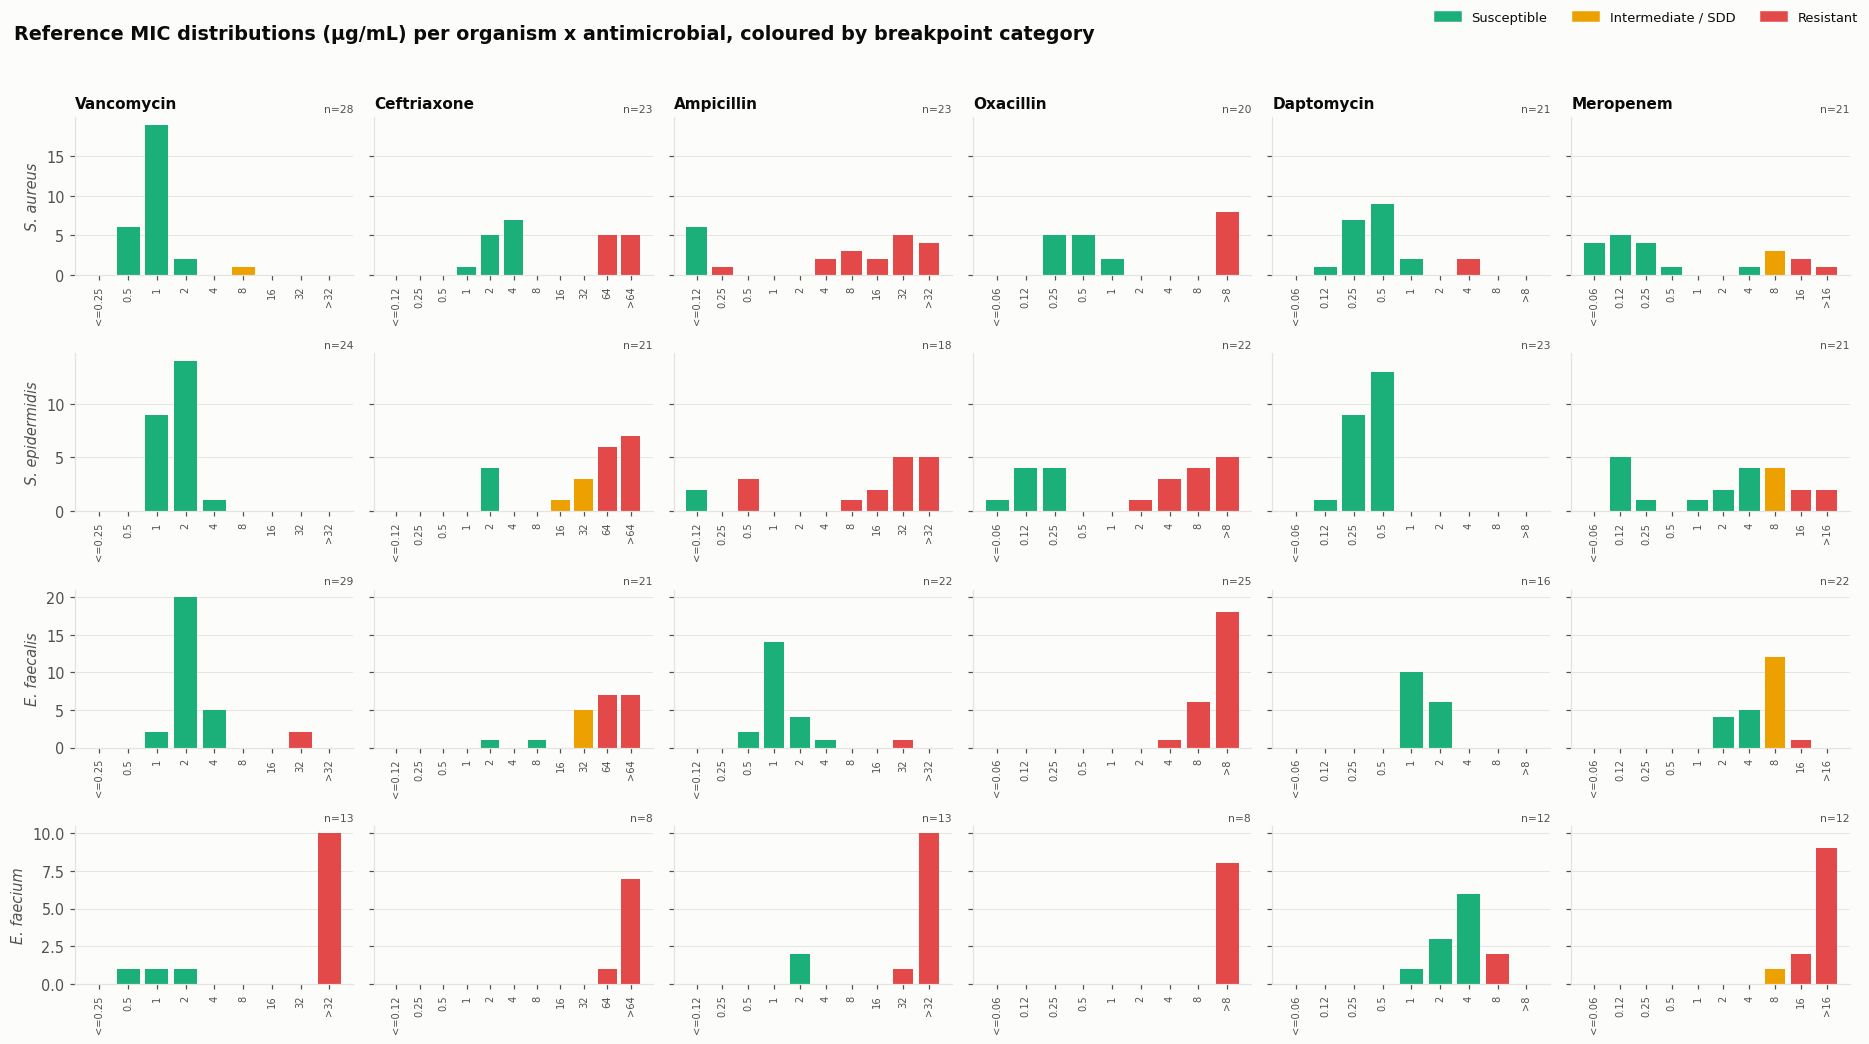

In [12]:
from src.analysis import ast_analysis as aa
ares = aa.run(raw); plt.close("all")
from src.data.make_dataset import load_breakpoints
bp = load_breakpoints()
aa.plot_mic_distributions(ares["series"], bp);

cat                                           S     I      R   n
Organism                   Antimicrobial                        
Enterococcus faecalis      Ampicillin      95.5   0.0    4.5  22
                           Ceftriaxone      9.5  23.8   66.7  21
                           Daptomycin     100.0   0.0    0.0  16
                           Meropenem       40.9  54.5    4.5  22
                           Oxacillin        0.0   0.0  100.0  25
                           Vancomycin      93.1   0.0    6.9  29
Enterococcus faecium       Ampicillin      15.4   0.0   84.6  13
                           Ceftriaxone      0.0   0.0  100.0   8
                           Daptomycin      83.3   0.0   16.7  12
                           Meropenem        0.0   8.3   91.7  12
                           Oxacillin        0.0   0.0  100.0   8
                           Vancomycin      23.1   0.0   76.9  13
Staphylococcus aureus      Ampicillin      26.1   0.0   73.9  23
                           Ceftriaxone     56.5   0.0   43.5  23
                           Daptomycin      90.5   0.0    9.5  21
                           Meropenem       71.4  14.3   14.3  21
                           Oxacillin       60.0   0.0   40.0  20
                           Vancomycin      96.4   3.6    0.0  28
Staphylococcus epidermidis Ampicillin      11.1   0.0   88.9  18
                           Ceftriaxone     19.0  19.0   61.9  21
                           Daptomycin     100.0   0.0    0.0  23
                           Meropenem       61.9  19.0   19.0  21
                           Oxacillin       40.9   0.0   59.1  22
                           Vancomycin     100.0   0.0    0.0  24

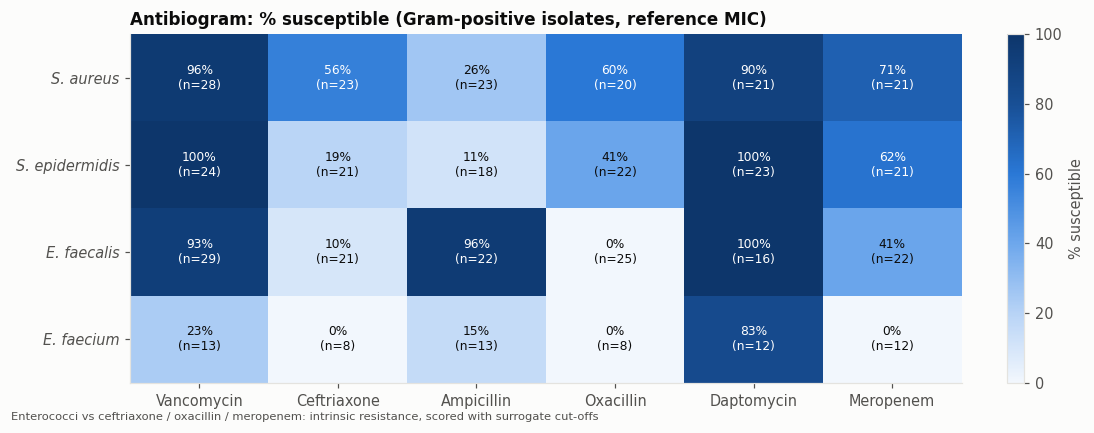

In [13]:
aa.plot_antibiogram(ares["antibiogram"])
ares["antibiogram"]

## 5. Growth readouts and the MIC step

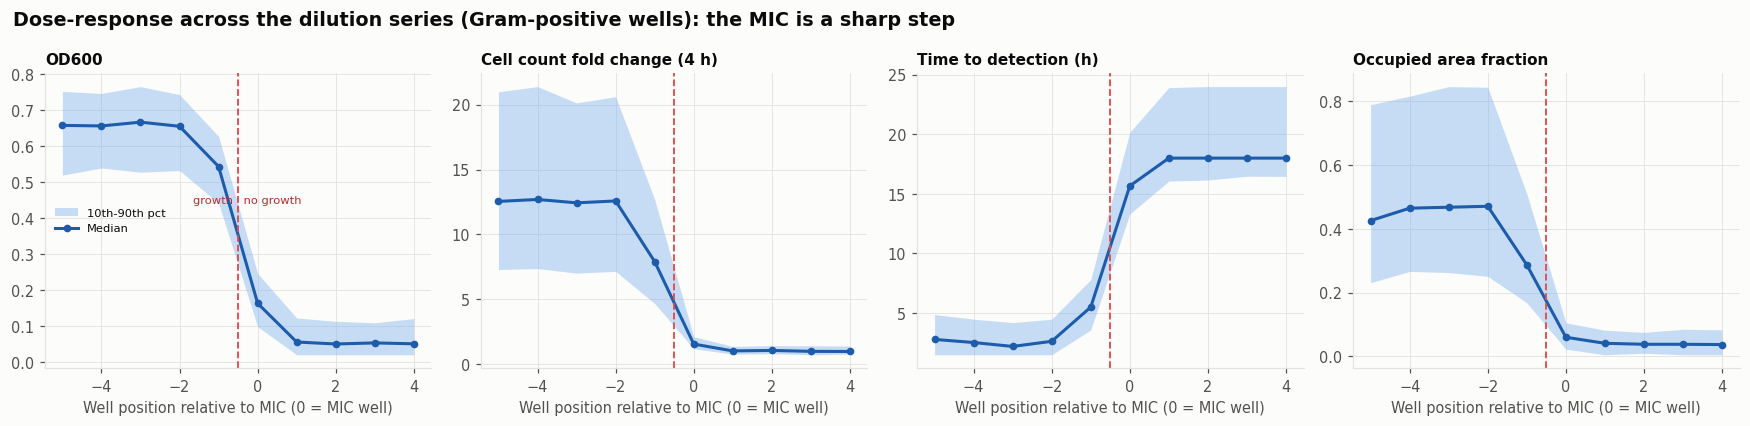

In [14]:
aa.plot_dose_response(raw);

Growth readouts change sharply between the last growth well and the MIC well. Wells right at the step are the hardest to read, so they drive most exact-MIC (AA) errors, while essential agreement (±1 dilution) stays high.

,feature,rank_biserial,univariate_auc,q_value
0,Cell_Count_T4h,0.9346,0.9673,0.0000
1,Growth_Fold_Change,0.9355,0.9678,0.0000
2,Occupied_Area_Fraction,0.9286,0.9643,0.0000
3,Time_to_Detection_h,-0.9388,0.9694,0.0000
4,OD600_Read,0.9452,0.9726,0.0000
5,Cell_Elongation_Index,-0.2975,0.6487,0.0000
6,Mean_Cell_Area_um2,-0.1987,0.5993,0.0000
7,Incubation_Time_h,-0.0506,0.5253,0.0000
8,Growth_Control_OD600,-0.0825,0.5413,0.0000
9,Inoculum_log10_CFU_mL,0.0415,0.5207,0.0046


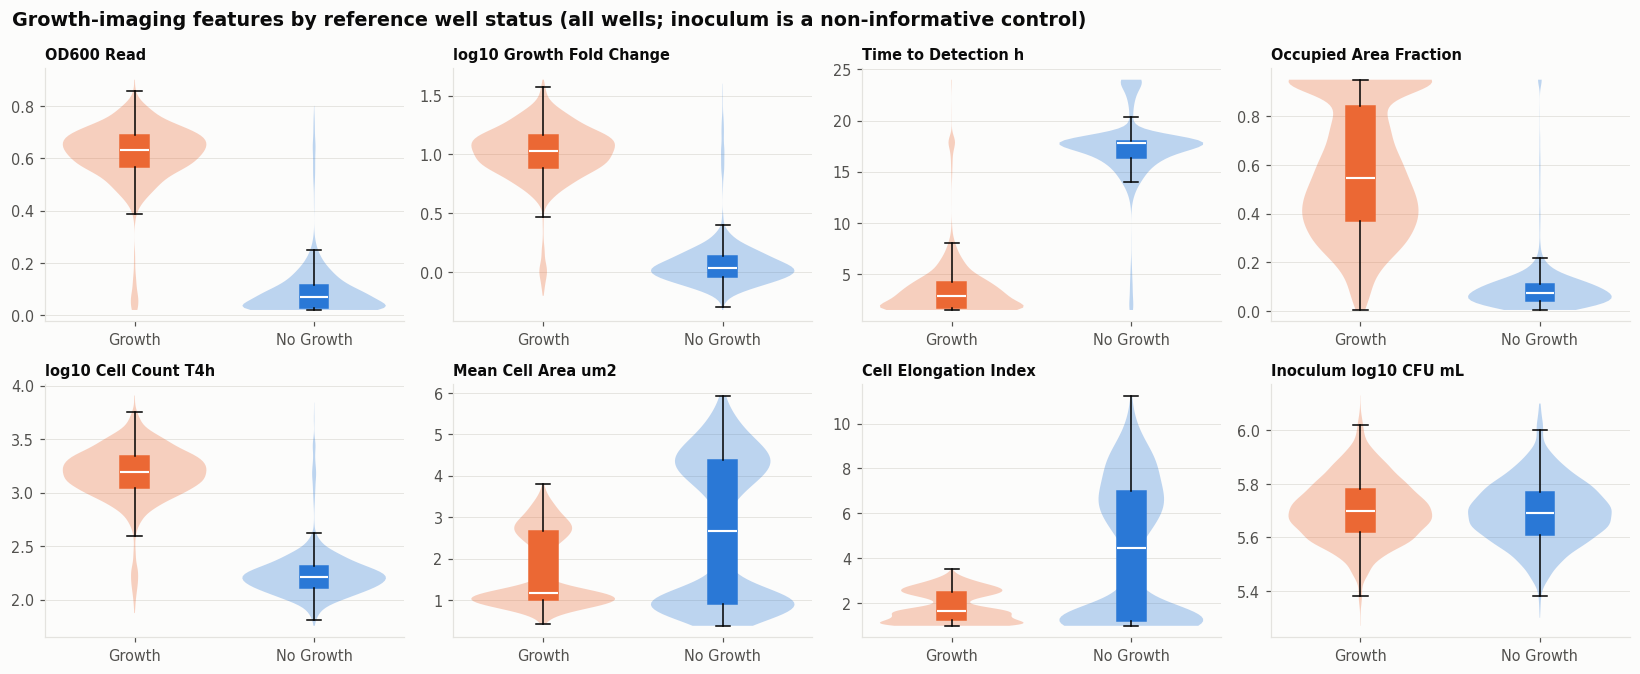

In [15]:
aa.plot_growth_features(raw)
ares["growth_tests"][["feature", "rank_biserial", "univariate_auc", "q_value"]].round(4)

## 6. Genotype-phenotype concordance

,pair,n,marker+ R,marker+ not R,marker- R,marker- not R,concordance
0,mecA vs oxacillin (staphylococci),42,21,0,0,21,1.0
1,vanA/vanB vs vancomycin (enterococci),42,12,0,0,30,1.0


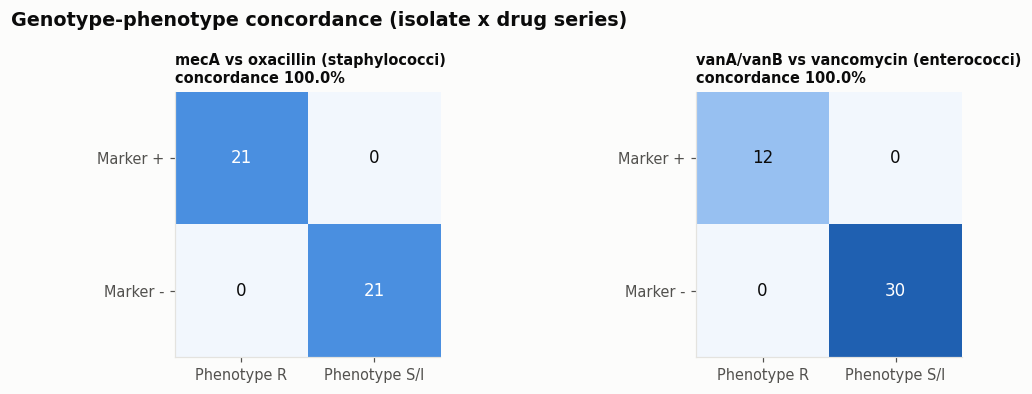

In [16]:
aa.plot_marker(ares["marker"])
ares["marker"]

**Summary**

* Gram stain features and ID tests are individually strong but imperfect at the well level (image failures, 3-5% test misreads).
* The MIC distributions are bimodal for acquired resistance (MRSA / MR-CoNS, VRE, ampicillin-resistant *E. faecium*) and high for intrinsic resistance.
* Growth readouts show a sharp step at the MIC, which is what makes an MIC call from well-level growth predictions possible (notebooks 03-04).